# here we define 1st Galaxy for comparison

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from synthesizer.particle import Galaxy, Stars, BlackHoles
from unyt import Myr, Msun, yr, Mpc, cm, K
from synthesizer.particle.stars import sample_sfzh


In [55]:
# Create Galaxy and its components (as Particle objects)
N =100
ages = np.random.rand(N) * 100 * Myr
metallicities = np.random.rand(N) / 100
initial_masses = np.ones(N) * 1e6 * Msun

part_stars = Stars(
    initial_masses=initial_masses,
    ages=ages,
    metallicities=metallicities,
)

# Make fake properties
n = 4
masses = 10 ** np.random.uniform(low=6, high=8, size=n) * Msun
coordinates = np.random.normal(0, 1.5, (n, 3)) * Mpc
accretion_rates = 10 ** np.random.uniform(low=-2, high=1, size=n) * Msun / yr
metallicities = np.full(n, 0.01)
tau_v = 0.5 * np.ones(n)

# And get the black holes object
blackholes = BlackHoles(
    masses=masses,
    coordinates=coordinates,
    accretion_rates=accretion_rates,
    metallicities=metallicities,
    tau_v=tau_v,
    ionisation_parameter_nlr=0.01,
    hydrogen_density_nlr=1e4 * cm**-3,
    ionisation_parameter_blr=0.1,
    hydrogen_density_blr=1e10 * cm**-3,
)

# And create the galaxy
galaxy = Galaxy(
    stars=part_stars,
    black_holes=blackholes,
    redshift=1,
)

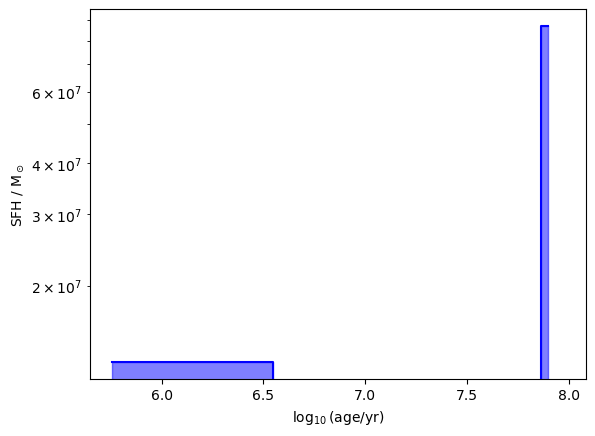

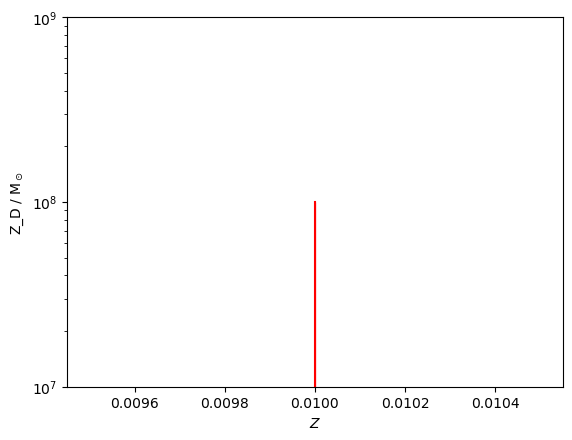

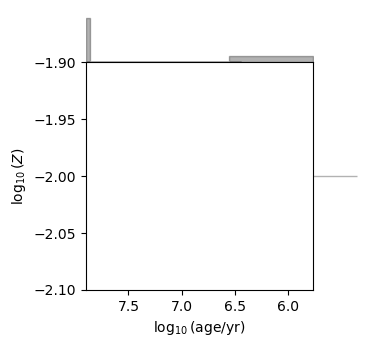

(<Figure size 350x350 with 3 Axes>,
 <Axes: xlabel='$\\log_{10}(\\mathrm{age}/\\mathrm{yr})$', ylabel='$\\log_{10}(Z)$'>)

In [56]:
part_stars.plot_sfh(log10ages= np.log10(ages))
part_stars.plot_metal_dist(metallicities=metallicities)
part_stars.get_sfzh(log10ages=np.log10(ages), metallicities=metallicities )
part_stars.plot_sfzh()


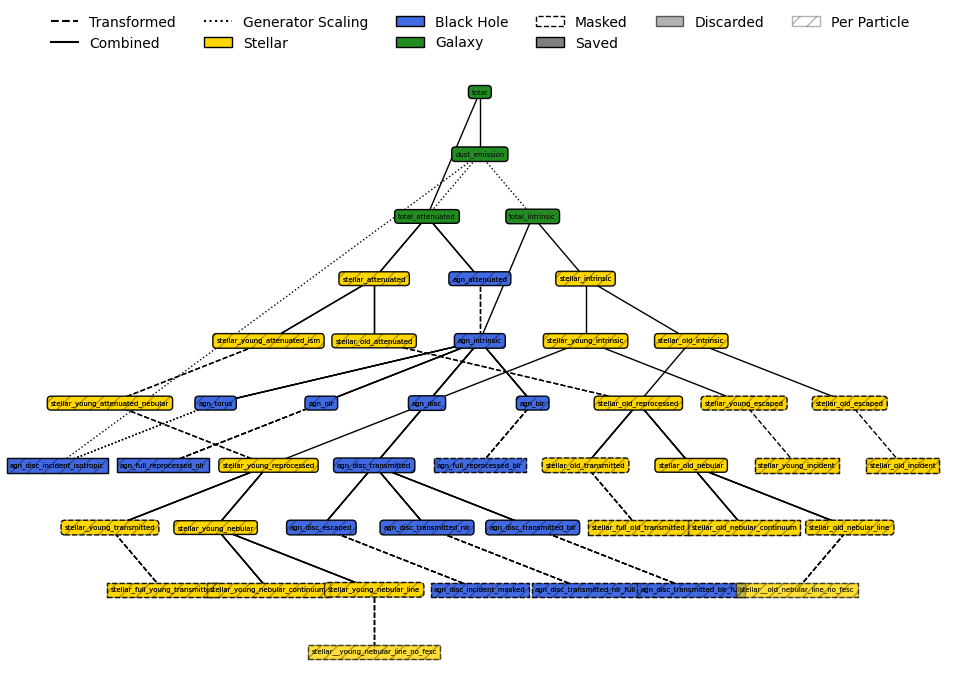

(<Figure size 1200x800 with 1 Axes>, <Axes: >)

In [35]:
from synthesizer.emission_models import (
    BimodalPacmanEmission,
    Blackbody,
    DustEmission,
    EmissionModel,
    Greybody,
    UnifiedAGN,
)
from synthesizer.emission_models.attenuation import PowerLaw
from synthesizer.grid import Grid
from synthesizer.parametric import SFH, ZDist
from synthesizer.parametric import Stars as ParametricStars
from synthesizer.particle import BlackHoles, Galaxy
from synthesizer.particle.stars import sample_sfzh

# Get the grids which we'll need for extraction
grid_name = "test_grid"
grid = Grid(grid_name)
nlr_grid = Grid("test_grid_agn-nlr")
blr_grid = Grid("test_grid_agn-blr")

# Get the stellar pacman model
pc_model = BimodalPacmanEmission(
    grid=grid,
    tau_v_ism=1.0,
    tau_v_birth=0.7,
    dust_curve_ism=PowerLaw(slope=-1.3),
    dust_curve_birth=PowerLaw(slope=-0.7),
    dust_emission_ism=Blackbody(temperature=100 * K),
    dust_emission_birth=Blackbody(temperature=30 * K),
    fesc=0.2,
    fesc_ly_alpha=0.9,
    label="stellar_total",
)
pc_model.set_per_particle(True)

# Initialise the UnifiedAGN model
uniagn = UnifiedAGN(
    nlr_grid,
    blr_grid,
    ionisation_parameter_nlr=0.01,
    hydrogen_density_nlr=1e4 * cm**-3,
    ionisation_parameter_blr=0.1,
    hydrogen_density_blr=1e10 * cm**-3,
    torus_emission_model=Greybody(1000 * K, 1.5),
    diffuse_dust_curve=PowerLaw(slope=-1.0),
    per_particle=True,
)
uniagn.add_label_prefix("agn")
pc_model.add_label_prefix("stellar")


gal_intrinsic = EmissionModel(
    label="total_intrinsic",
    combine=(uniagn["agn_intrinsic"], pc_model["stellar_intrinsic"]),
    emitter="galaxy",
)

gal_attenuated = EmissionModel(
    label="total_attenuated",
    combine=(uniagn["agn_attenuated"], pc_model["stellar_attenuated"]),
    related_models=(gal_intrinsic,),
    emitter="galaxy",
)

# And now include the dust emission
gal_dust = DustEmission(
    dust_emission_model=Greybody(30 * K, 1.2),
    dust_lum_intrinsic=gal_intrinsic,
    dust_lum_attenuated=gal_attenuated,
    emitter="galaxy",
    label="dust_emission",
)

gal_total_1 = EmissionModel(
    label="total",
    combine=(gal_attenuated, gal_dust),
    related_models=(gal_intrinsic,),
    emitter="galaxy",
)

gal_total_1.plot_emission_tree(fontsize=5, figsize=(12, 8), show=True)

In [41]:
gal_total_1.save_spectra(
    "total",
    "dust_emission",
    "total_attenuated",
    "total_intrinsic",
    "stellar_intrinsic",
    "stellar_attenuated",
)

In [42]:
# Define the number of stellar particles we want
n = 100

# Sample the parametric SFZH, producing a particle Stars object
# we will also pass some keyword arguments for some example attributes
N = 20
ages = np.random.rand(N) * 100 * Myr
metallicities = np.random.rand(N) / 100
initial_masses = np.ones(N) * 1e6 * Msun

part_stars = Stars(
    initial_masses=initial_masses,
    ages=ages,
    metallicities=metallicities,
)

# Make fake properties
n = 4
masses = 10 ** np.random.uniform(low=6, high=8, size=n) * Msun
coordinates = np.random.normal(0, 1.5, (n, 3)) * Mpc
accretion_rates = 10 ** np.random.uniform(low=-2, high=1, size=n) * Msun / yr
metallicities = np.full(n, 0.01)
tau_v = 0.5 * np.ones(n)

# And get the black holes object
blackholes = BlackHoles(
    masses=masses,
    coordinates=coordinates,
    accretion_rates=accretion_rates,
    metallicities=metallicities,
    tau_v=tau_v,
    ionisation_parameter_nlr=0.01,
    hydrogen_density_nlr=1e4 * cm**-3,
    ionisation_parameter_blr=0.1,
    hydrogen_density_blr=1e10 * cm**-3,
)

# And create the galaxy
galaxy = Galaxy(
    stars=part_stars,
    black_holes=blackholes,
    redshift=1,
)

/Users/jiaheak/miniforge3/envs/galaxy_synthesis_env/lib/python3.14/site-packages/unyt/array.py:1900: RuntimeWarning: overflow encountered in exp
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)
/Users/jiaheak/miniforge3/envs/galaxy_synthesis_env/lib/python3.14/site-packages/unyt/array.py:2040: RuntimeWarning: overflow encountered in multiply
  out_arr = func(


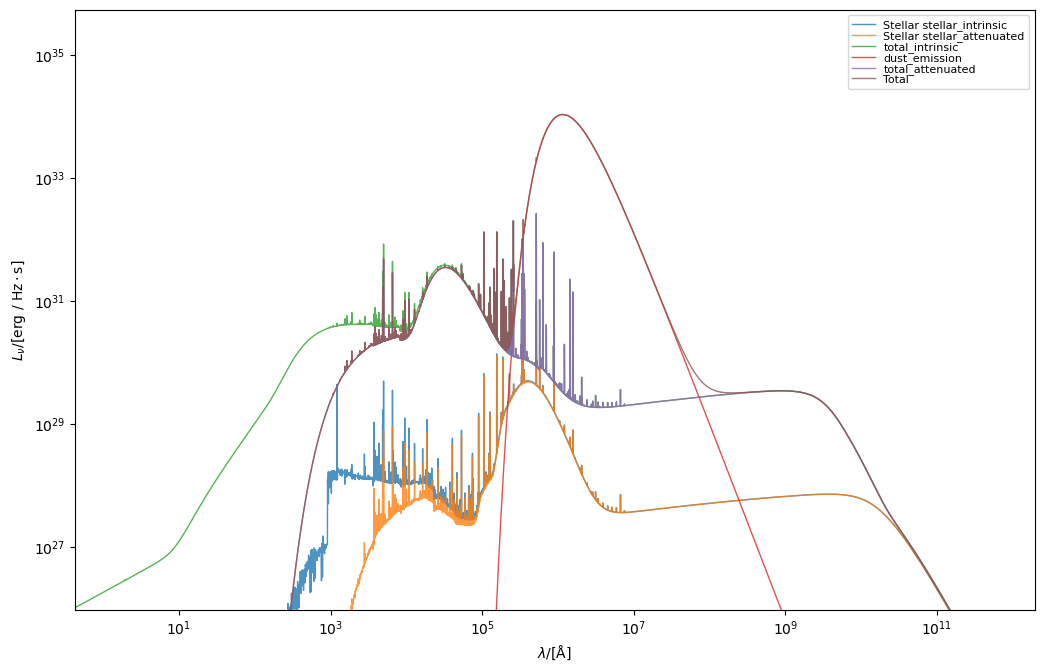

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: xlabel='$\\lambda/[\\mathrm{\\AA}]$', ylabel='$L_{\\nu}/[\\mathrm{\\rm{erg} \\ / \\ \\rm{Hz \\cdot \\rm{s}}}]$'>)

In [57]:
spectra = galaxy.get_spectra(gal_total_1)
galaxy.plot_spectra(
    combined_spectra=True,
    stellar_spectra=True,
    black_hole_spectra=False,
    show=True,
    figsize=(12, 10),
)

## Apply attenuation

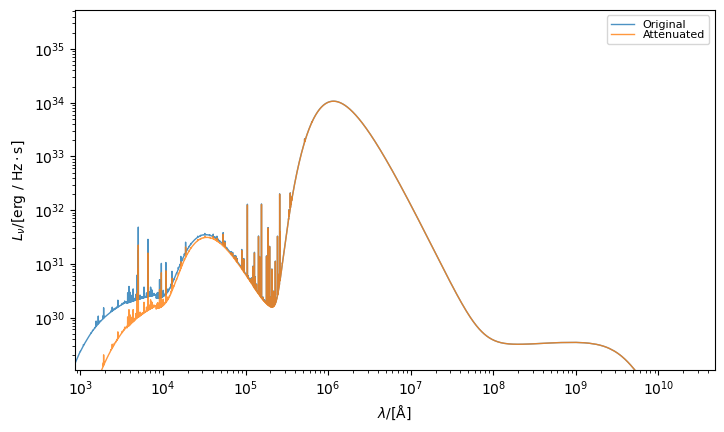

In [67]:
from synthesizer.emission_models.attenuation import PowerLaw

spectra_att = spectra.apply_attenuation(tau_v=0.7, dust_curve=PowerLaw(-1.0))

# Integrate the multidimensional spectra
int_spectra = spectra.sum()
int_spectra_att = spectra_att.sum()

fig, ax = int_spectra.plot_spectra(label="Original", figsize=(8,6))
fig, ax = int_spectra_att.plot_spectra(label="Attenuated", fig=fig, ax=ax)
